# Dự báo Tiêu thụ Năng lượng PJME - ARIMA vs Holt-Winters

Phân tích và dự báo mức tiêu thụ điện (Megawatts) sử dụng hai mô hình:
- **ARIMA** (AutoRegressive Integrated Moving Average)
- **Holt-Winters** (Triple Exponential Smoothing)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12
print('Thư viện đã được import thành công!')

Thư viện đã được import thành công!


## 1. Tải và Khám phá Dữ liệu

In [2]:
# Tải dữ liệu
df = pd.read_csv('PJME_hourly.csv')

# Xử lý datetime và đặt index
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime').sort_index()
df.columns = ['MW']

print('=== THÔNG TIN TỔNG QUAN ===')
print(f'Số lượng quan sát: {len(df):,}')
print(f'Thời gian bắt đầu: {df.index.min()}')
print(f'Thời gian kết thúc: {df.index.max()}')
print(f'\nThống kê mô tả:')
print(df.describe().round(2))

=== THÔNG TIN TỔNG QUAN ===
Số lượng quan sát: 145,366
Thời gian bắt đầu: 2002-01-01 01:00:00
Thời gian kết thúc: 2018-08-03 00:00:00

Thống kê mô tả:
              MW
count  145366.00
mean    32080.22
std      6464.01
min     14544.00
25%     27573.00
50%     31421.00
75%     35650.00
max     62009.00


In [3]:
# Kiểm tra missing values
print(f'Số giá trị null: {df.isnull().sum().values[0]}')
df = df.dropna()
print(f'Số quan sát sau khi xử lý: {len(df):,}')

Số giá trị null: 0
Số quan sát sau khi xử lý: 145,366


## 2. Trực quan hóa Dữ liệu Gốc

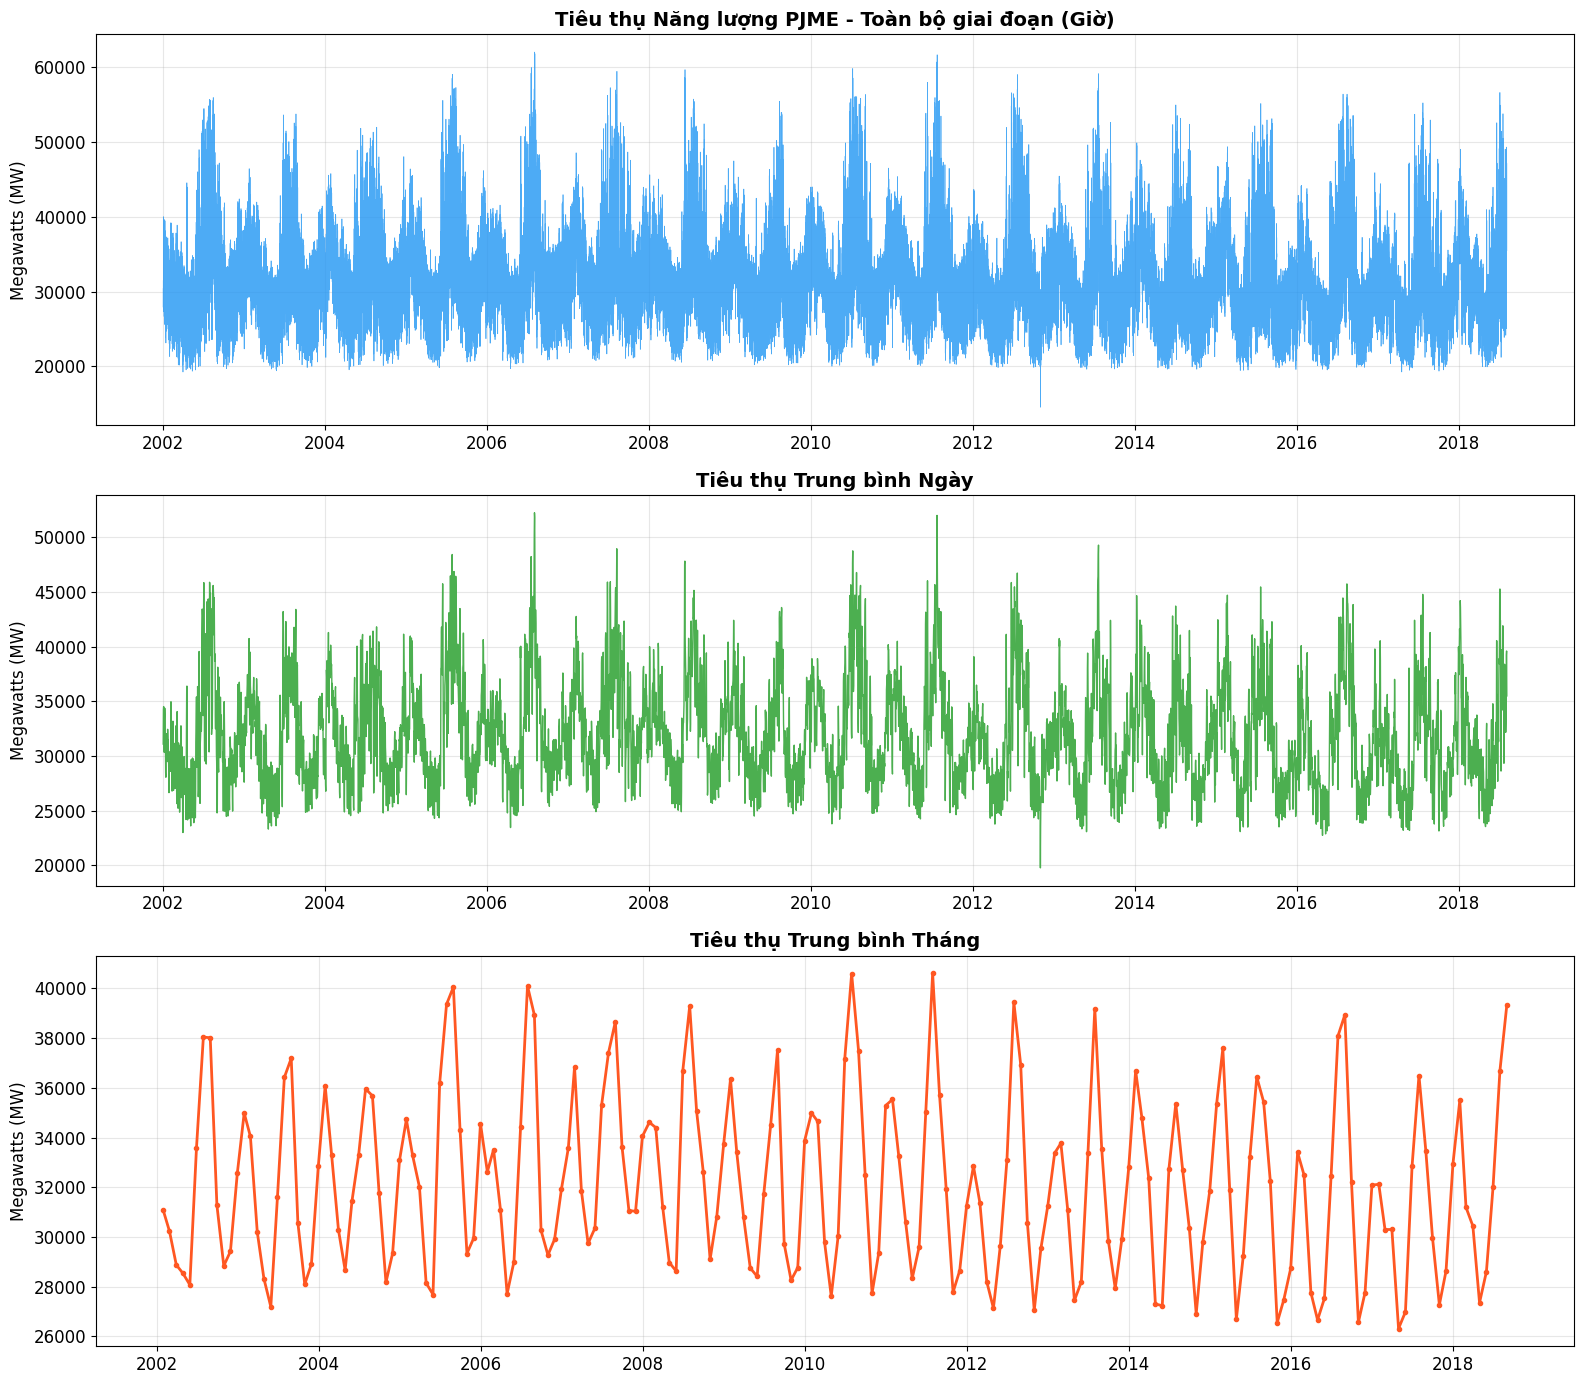

Biểu đồ đã lưu: 01_raw_data.png


In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# Toàn bộ chuỗi thời gian
axes[0].plot(df.index, df['MW'], color='#2196F3', linewidth=0.5, alpha=0.8)
axes[0].set_title('Tiêu thụ Năng lượng PJME - Toàn bộ giai đoạn (Giờ)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Megawatts (MW)')
axes[0].grid(True, alpha=0.3)

# Dữ liệu trung bình theo ngày
daily = df.resample('D').mean()
axes[1].plot(daily.index, daily['MW'], color='#4CAF50', linewidth=1)
axes[1].set_title('Tiêu thụ Trung bình Ngày', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Megawatts (MW)')
axes[1].grid(True, alpha=0.3)

# Trung bình theo tháng
monthly = df.resample('ME').mean()
axes[2].plot(monthly.index, monthly['MW'], color='#FF5722', linewidth=2, marker='o', markersize=3)
axes[2].set_title('Tiêu thụ Trung bình Tháng', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Megawatts (MW)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('Biểu đồ đã lưu: 01_raw_data.png')

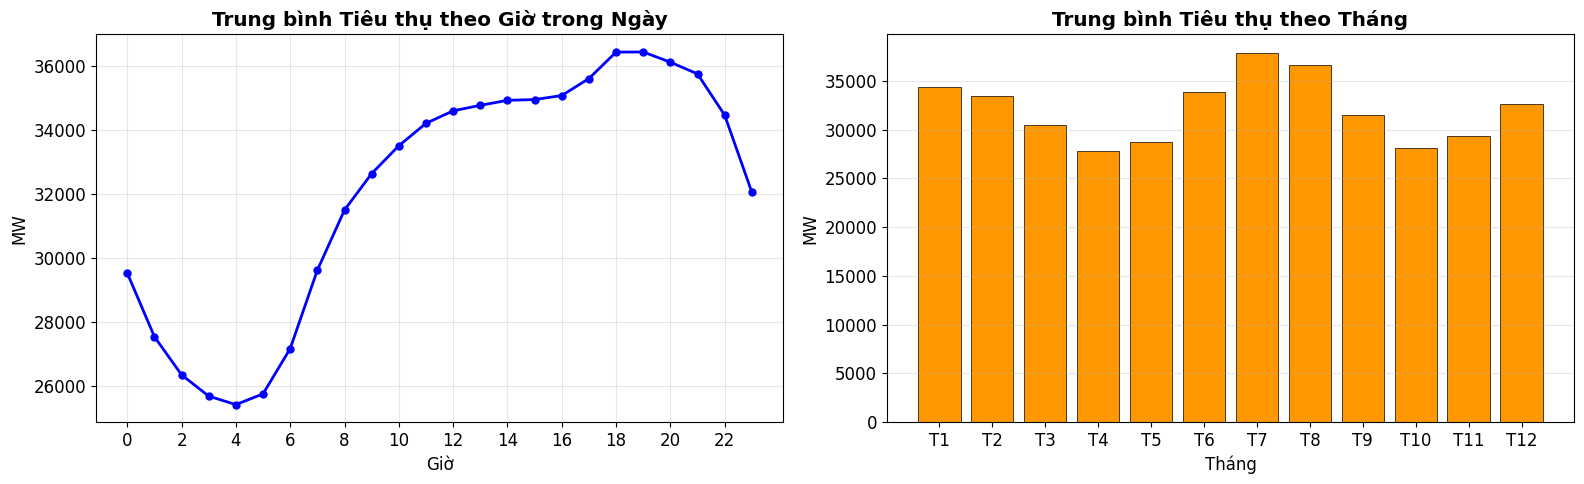

In [5]:
# Phân tích tính mùa vụ
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Theo giờ trong ngày
hourly_avg = df.groupby(df.index.hour)['MW'].mean()
axes[0].plot(hourly_avg.index, hourly_avg.values, 'b-o', linewidth=2, markersize=5)
axes[0].set_title('Trung bình Tiêu thụ theo Giờ trong Ngày', fontweight='bold')
axes[0].set_xlabel('Giờ')
axes[0].set_ylabel('MW')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(0, 24, 2))

# Theo tháng trong năm
monthly_avg = df.groupby(df.index.month)['MW'].mean()
month_names = ['T1','T2','T3','T4','T5','T6','T7','T8','T9','T10','T11','T12']
axes[1].bar(month_names, monthly_avg.values, color='#FF9800', edgecolor='black', linewidth=0.5)
axes[1].set_title('Trung bình Tiêu thụ theo Tháng', fontweight='bold')
axes[1].set_xlabel('Tháng')
axes[1].set_ylabel('MW')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 3. Chuẩn bị Dữ liệu - Sử dụng Dữ liệu Ngày (Tối ưu cho Mô hình)

In [17]:
# Dùng dữ liệu trung bình ngày để mô hình chạy nhanh hơn
# Lấy 2 năm gần nhất để tập trung
daily = df.resample('D').mean()
daily.columns = ['MW']

# Sử dụng 730 ngày (2 năm) gần nhất
data = daily.copy()
print(f'Dữ liệu phân tích: {len(data)} ngày ({data.index.min().date()} → {data.index.max().date()})')

# Chia train/test (80/20)
split_point = int(len(data) * 0.80)
train = data.iloc[:split_point]
test  = data.iloc[split_point:]

print(f'\nTập Train: {len(train)} ngày ({train.index.min().date()} → {train.index.max().date()})')
print(f'Tập Test:  {len(test)} ngày ({test.index.min().date()} → {test.index.max().date()})')

Dữ liệu phân tích: 6059 ngày (2002-01-01 → 2018-08-03)

Tập Train: 4847 ngày (2002-01-01 → 2015-04-09)
Tập Test:  1212 ngày (2015-04-10 → 2018-08-03)


## 4. Kiểm định Tính Dừng (ADF Test)

In [18]:
def adf_test(series, name=''):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'=== ADF Test: {name} ===')
    print(f'ADF Statistic : {result[0]:.4f}')
    print(f'p-value       : {result[1]:.4f}')
    print(f'Critical Values:')
    for key, val in result[4].items():
        print(f'   {key}: {val:.4f}')
    if result[1] < 0.05:
        print('→ Kết luận: Chuỗi DỪNG (p < 0.05) ✓')
    else:
        print('→ Kết luận: Chuỗi KHÔNG DỪNG (p >= 0.05), cần sai phân')
    print()

adf_test(train['MW'], 'Dữ liệu gốc')

# Sai phân bậc 1
diff1 = train['MW'].diff().dropna()
adf_test(diff1, 'Sai phân bậc 1')

=== ADF Test: Dữ liệu gốc ===
ADF Statistic : -8.2227
p-value       : 0.0000
Critical Values:
   1%: -3.4317
   5%: -2.8621
   10%: -2.5671
→ Kết luận: Chuỗi DỪNG (p < 0.05) ✓

=== ADF Test: Sai phân bậc 1 ===
ADF Statistic : -13.7887
p-value       : 0.0000
Critical Values:
   1%: -3.4317
   5%: -2.8621
   10%: -2.5671
→ Kết luận: Chuỗi DỪNG (p < 0.05) ✓



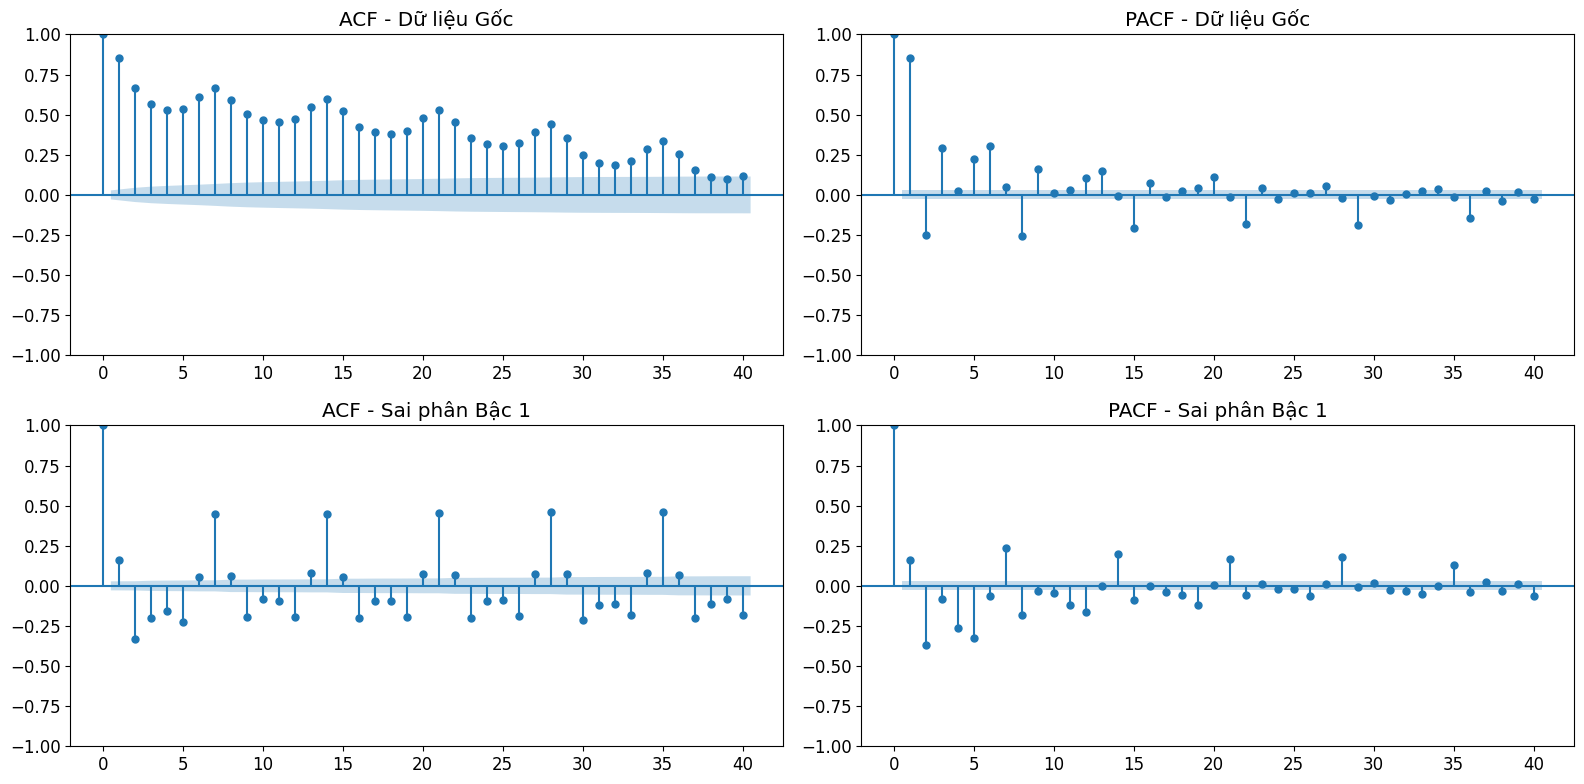

In [19]:
# ACF và PACF plot để xác định tham số ARIMA
fig, axes = plt.subplots(2, 2, figsize=(16, 8))

plot_acf(train['MW'], lags=40, ax=axes[0,0], title='ACF - Dữ liệu Gốc')
plot_pacf(train['MW'], lags=40, ax=axes[0,1], title='PACF - Dữ liệu Gốc')
plot_acf(diff1, lags=40, ax=axes[1,0], title='ACF - Sai phân Bậc 1')
plot_pacf(diff1, lags=40, ax=axes[1,1], title='PACF - Sai phân Bậc 1')

plt.tight_layout()
plt.savefig('03_acf_pacf.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Mô hình ARIMA

In [20]:
print('=== HUẤN LUYỆN MÔ HÌNH ARIMA(2,1,2) ===')
print('(p=2 từ PACF, d=1 do chuỗi không dừng, q=2 từ ACF)\n')

# ARIMA(2,1,2) - tham số phổ biến cho dữ liệu năng lượng
arima_model = SARIMAX(
    train['MW'],
    order=(2, 1, 2),
    trend='c',
    enforce_stationarity=False,
    enforce_invertibility=False
)
arima_fit = arima_model.fit(disp=False)

print(arima_fit.summary().tables[0])
print('\n--- Tham số mô hình ---')
print(arima_fit.summary().tables[1])

=== HUẤN LUYỆN MÔ HÌNH ARIMA(2,1,2) ===
(p=2 từ PACF, d=1 do chuỗi không dừng, q=2 từ ACF)

                               SARIMAX Results                                
Dep. Variable:                     MW   No. Observations:                 4847
Model:               SARIMAX(2, 1, 2)   Log Likelihood              -44095.462
Date:                Sat, 30 May 2026   AIC                          88202.925
Time:                        16:03:33   BIC                          88241.836
Sample:                    01-01-2002   HQIC                         88216.585
                         - 04-09-2015                                         
Covariance Type:                  opg                                         

--- Tham số mô hình ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -2.3766      5.287     -0.449      0.653     -12.740       7.986
ar.L1         

In [21]:
# Dự báo trên tập test
n_test = len(test)
arima_pred = arima_fit.forecast(steps=n_test)
arima_pred.index = test.index

# Dự báo tương lai 30 ngày
arima_future = arima_fit.forecast(steps=n_test + 30)
arima_future_30 = arima_future.iloc[-30:]

# Tính độ chính xác ARIMA
arima_mae  = mean_absolute_error(test['MW'], arima_pred)
arima_rmse = np.sqrt(mean_squared_error(test['MW'], arima_pred))
arima_mape = np.mean(np.abs((test['MW'] - arima_pred) / test['MW'])) * 100

print('=== KẾT QUẢ ARIMA(2,1,2) ===')
print(f'MAE  : {arima_mae:,.2f} MW')
print(f'RMSE : {arima_rmse:,.2f} MW')
print(f'MAPE : {arima_mape:.2f}%')
print(f'AIC  : {arima_fit.aic:.2f}')
print(f'BIC  : {arima_fit.bic:.2f}')

=== KẾT QUẢ ARIMA(2,1,2) ===
MAE  : 5,109.64 MW
RMSE : 6,669.11 MW
MAPE : 15.04%
AIC  : 88202.92
BIC  : 88241.84


## 6. Mô hình Holt-Winters (Triple Exponential Smoothing)

In [22]:
print('=== HUẤN LUYỆN MÔ HÌNH HOLT-WINTERS ===')
print('(seasonal_periods=7: chu kỳ tuần, trend=add, seasonal=add)\n')

# Holt-Winters với chu kỳ mùa vụ 7 ngày (theo tuần)
hw_model = ExponentialSmoothing(
    train['MW'],
    trend='add',
    seasonal='add',
    seasonal_periods=7,  # Chu kỳ tuần
    initialization_method='estimated'
)
hw_fit = hw_model.fit(optimized=True, use_brute=True)

print('Tham số tối ưu:')
print(f'  Alpha (level)    : {hw_fit.params["smoothing_level"]:.4f}')
print(f'  Beta  (trend)    : {hw_fit.params["smoothing_trend"]:.4f}')
print(f'  Gamma (seasonal) : {hw_fit.params["smoothing_seasonal"]:.4f}')
print(f'  SSE              : {hw_fit.sse:,.2f}')
print(f'  AIC              : {hw_fit.aic:.2f}')

=== HUẤN LUYỆN MÔ HÌNH HOLT-WINTERS ===
(seasonal_periods=7: chu kỳ tuần, trend=add, seasonal=add)

Tham số tối ưu:
  Alpha (level)    : 0.9953
  Beta  (trend)    : 0.0000
  Gamma (seasonal) : 0.0047
  SSE              : 17,064,575,730.22
  AIC              : 73086.43


In [23]:
# Dự báo Holt-Winters
hw_pred = hw_fit.forecast(steps=n_test)
hw_pred.index = test.index

hw_future = hw_fit.forecast(steps=n_test + 30)
hw_future_30 = hw_future.iloc[-30:]

# Tính độ chính xác HW
hw_mae  = mean_absolute_error(test['MW'], hw_pred)
hw_rmse = np.sqrt(mean_squared_error(test['MW'], hw_pred))
hw_mape = np.mean(np.abs((test['MW'] - hw_pred) / test['MW'])) * 100

print('=== KẾT QUẢ HOLT-WINTERS ===')
print(f'MAE  : {hw_mae:,.2f} MW')
print(f'RMSE : {hw_rmse:,.2f} MW')
print(f'MAPE : {hw_mape:.2f}%')
print(f'AIC  : {hw_fit.aic:.2f}')

=== KẾT QUẢ HOLT-WINTERS ===
MAE  : 8,371.32 MW
RMSE : 9,791.96 MW
MAPE : 28.58%
AIC  : 73086.43


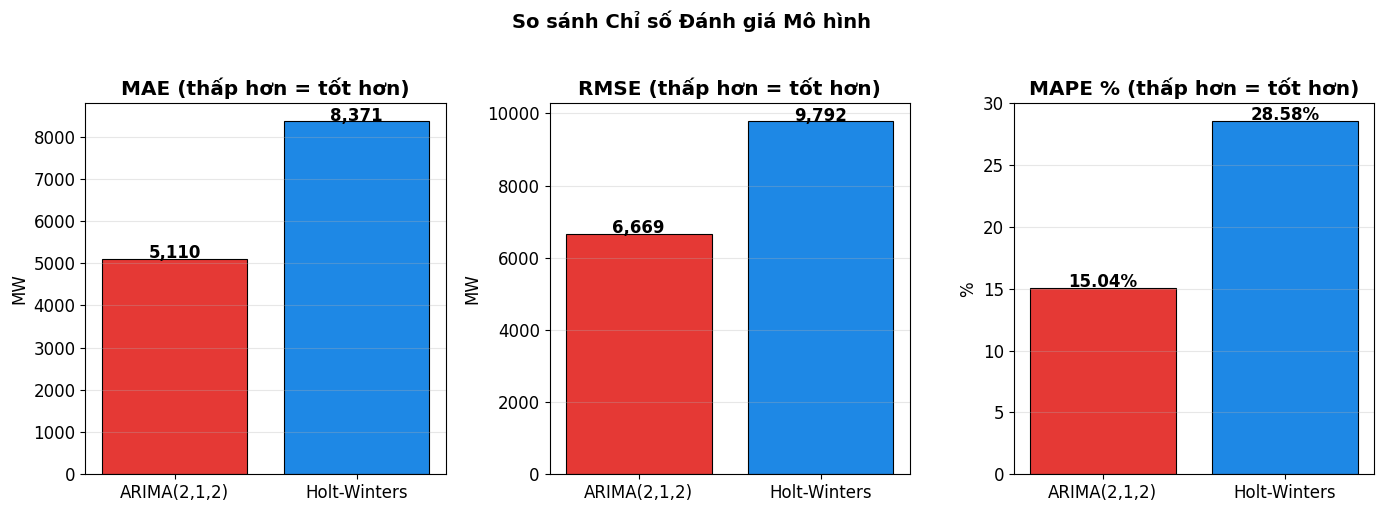

In [27]:
# Biểu đồ so sánh chỉ số
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

models = ['ARIMA(2,1,2)', 'Holt-Winters']
colors = ['#E53935', '#1E88E5']

# MAE
axes[0].bar(models, [arima_mae, hw_mae], color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('MAE (thấp hơn = tốt hơn)', fontweight='bold')
axes[0].set_ylabel('MW')
for i, v in enumerate([arima_mae, hw_mae]):
    axes[0].text(i, v + 10, f'{v:,.0f}', ha='center', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# RMSE
axes[1].bar(models, [arima_rmse, hw_rmse], color=colors, edgecolor='black', linewidth=0.8)
axes[1].set_title('RMSE (thấp hơn = tốt hơn)', fontweight='bold')
axes[1].set_ylabel('MW')
for i, v in enumerate([arima_rmse, hw_rmse]):
    axes[1].text(i, v + 10, f'{v:,.0f}', ha='center', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# MAPE
axes[2].bar(models, [arima_mape, hw_mape], color=colors, edgecolor='black', linewidth=0.8)
axes[2].set_title('MAPE % (thấp hơn = tốt hơn)', fontweight='bold')
axes[2].set_ylabel('%')
for i, v in enumerate([arima_mape, hw_mape]):
    axes[2].text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('So sánh Chỉ số Đánh giá Mô hình', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('06_metrics_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

| Chỉ số | ARIMA (2,1,2) | Holt-Winters | Chênh lệch |
|---|---:|---:|---|
| MAE | 5,110 MW | 8,371 MW | ARIMA tốt hơn 39% |
| RMSE | 6,669 MW | 9,792 MW | ARIMA tốt hơn 32% |
| MAPE | 15.04% | 28.58% | ARIMA tốt hơn gần 2× |

## Nhìn vào các chỉ số đánh giá thì ARIMA tốt hơn Holt-Winters